# Preprossing and Initial Exploratory Analysis
## Loading the csv files into Pandas DataFrames

In [161]:
# Import pandas library to conduct the initial analysis and preprocessing
import pandas as pd

In [162]:
# Loading the csv files into pandas dataframes
gps_df = pd.read_csv('./data/gps_data.csv')
ship_bks_df = pd.read_csv('./data/shipment_bookings.csv')

In [163]:
# Quick check on the number of rows in each dataframe
gps_row_count = len(gps_df)
ship_bks_row_count = len(ship_bks_df)

print(f"Number of gps tracking records: {gps_row_count}")
print(f"Number of shipment booking records: {ship_bks_row_count}")

Number of gps tracking records: 641662
Number of shipment booking records: 3245


In [164]:
# Frist glance gps on the data
gps_df.head()

,SHIPMENT_NUMBER,LAT,LON,RECORD_TIMESTAMP
0,SEZHUK-230918-245388,53.291931,-1.072948,2023-10-09T19:25:00.000+0100
1,SEZHUK-230918-245388,53.400404,-1.078563,2023-10-09T19:40:00.000+0100
2,SEZHUK-230918-245388,53.574182,-1.215761,2023-10-09T19:55:00.000+0100
3,SEZHUK-230918-245388,53.706805,-1.336503,2023-10-09T20:10:00.000+0100
4,SEZHUK-230918-245388,53.747501,-1.640298,2023-10-09T20:25:00.000+0100


In [165]:
# Frist glance shipment bookings on the data
ship_bks_df.head()

,PROJECT_ID,SHIPMENT_NUMBER,CARRIER_DISPLAY_ID,VEHICLE_SIZE,VEHICLE_BUILD_UP,FIRST_COLLECTION_POST_CODE,LAST_DELIVERY_POST_CODE,FIRST_COLLECTION_LATITUDE,FIRST_COLLECTION_LONGITUDE,LAST_DELIVERY_LATITUDE,LAST_DELIVERY_LONGITUDE,FIRST_COLLECTION_SCHEDULE_EARLIEST,FIRST_COLLECTION_SCHEDULE_LATEST,LAST_DELIVERY_SCHEDULE_EARLIEST,LAST_DELIVERY_SCHEDULE_LATEST
0,5456fcfa-5b0c-428e-b322-240d508b6660,SEZHUK-231005-250448,CAUK000096,Tractor Unit,Curtain-Side 13.6M Trailer,PE29 2XR,EH48 2FB,52.315672,-0.157664,55.877803,-3.648558,2023-10-06T09:45:00.000Z,2023-10-06T10:00:00.000Z,2023-10-09T09:55:00.000Z,2023-10-09T10:25:00.000Z
1,eb7a9df0-4875-43d8-9060-c79c35eae2fb,SEZHUK-231217-275004,CAUK000660,Tractor Unit,Box 44ft,BD5 8LZ,RG19 4BQ,53.764125,-1.740145,51.398851,-1.231993,2023-12-19T14:20:00.000Z,2023-12-19T16:00:00.000Z,2023-12-20T06:00:00.000Z,2023-12-20T08:56:00.000Z
2,eb7a9df0-4875-43d8-9060-c79c35eae2fb,SEZHUK-231210-272018,CAUK000435,Tractor Unit,Box 44ft,BD5 8LZ,EN3 7QP,53.767302,-1.746560,51.660700,-0.022247,2023-12-14T01:20:00.000Z,2023-12-14T03:00:00.000Z,2023-12-14T07:03:00.000Z,2023-12-14T10:43:00.000Z
3,40415fe3-e446-4d1e-b141-3698b0dc47f3,SEZHUK-231211-272127,CAUK000096,Tractor Unit,Curtain-Side 13.6M Trailer,HP22 5BL,NG31 7UH,51.779657,-0.772897,52.888113,-0.634948,2023-12-13T09:00:00.000Z,2023-12-13T09:30:00.000Z,2023-12-13T15:30:00.000Z,2023-12-13T16:00:00.000Z
4,39a4e234-5d35-4d94-8e8a-b8bf6fe13953,SEZHUK-231025-256168,CAUK000155,Tractor Unit,Curtain Side,CV23 8BQ,G75 0ZZ,52.334853,-1.180450,55.735089,-4.168719,2023-11-07T14:00:00.000Z,2023-11-07T15:00:00.000Z,2023-11-07T23:00:00.000Z,2023-11-07T23:59:00.000Z


## Column Naming Discrepancy and Missing Column Noted

* **Note 1**: Upon reviewing the task document, we observed a discrepancy in the column naming. The task document references a column named **`CARRIER_ID`** in the Shipment Bookings data. However, in the dataset provided, the corresponding column is named **`CARRIER_DISPLAY_ID`**.

  To ensure consistency and alignment with the task requirements, we will rename **`CARRIER_DISPLAY_ID`** to **`CARRIER_ID`** in the dataset.

  This change ensures uniformity between the dataset and the task documentation.

* **Note 2**: The task document also mentions a column named **`SHIPPER_ID`**, but this column is not present in the Shipment Bookings data provided.

In [166]:
print(f"Columns in the Shipment Booking Data: {list(ship_bks_df.columns)}")

Columns in the Shipment Booking Data: ['PROJECT_ID', 'SHIPMENT_NUMBER', 'CARRIER_DISPLAY_ID', 'VEHICLE_SIZE', 'VEHICLE_BUILD_UP', 'FIRST_COLLECTION_POST_CODE', 'LAST_DELIVERY_POST_CODE', 'FIRST_COLLECTION_LATITUDE', 'FIRST_COLLECTION_LONGITUDE', 'LAST_DELIVERY_LATITUDE', 'LAST_DELIVERY_LONGITUDE', 'FIRST_COLLECTION_SCHEDULE_EARLIEST', 'FIRST_COLLECTION_SCHEDULE_LATEST', 'LAST_DELIVERY_SCHEDULE_EARLIEST', 'LAST_DELIVERY_SCHEDULE_LATEST']


In [167]:
# Renaming the CARRIER_DISPLAY_ID column to CARRIER_ID
ship_bks_df.rename(columns={'CARRIER_DISPLAY_ID': 'CARRIER_ID'}, inplace=True)

## Sanity check: Missing values

In [168]:
# First sanity check on the data: count the missing values in the data, column by column
def print_nan_columns(nan_columns, dataset_name):
    if nan_columns.empty:
        print(f"\nNo columns with missing values in {dataset_name}")
    else:
        print(f"\nColumns in {dataset_name} with missing values:")
        print("\t"+nan_columns.to_string(index=True).replace('\n', '\n\t'))  # This suppresses the dtype line

# Check for NaN values
gps_nan_colmns = gps_df.isna().sum() # This operation returns a Pandas Series where the indices are the column names that have at least one missing value
ship_bks_nan_colmns = ship_bks_df.isna().sum()

# Display results
print_nan_columns(gps_nan_colmns[gps_nan_colmns > 0], "GPS data")
print_nan_columns(ship_bks_nan_colmns[ship_bks_nan_colmns > 0], "Shipment bookings data")


No columns with missing values in GPS data

Columns in Shipment bookings data with missing values:
	FIRST_COLLECTION_POST_CODE    1
	LAST_DELIVERY_POST_CODE       4


### Oberservation on missing values and using an external API to fill them in

We note that there is no missing values in the GPS data.

And there is very few missing values in the Shipment Bookings data, a total of 5 missing values, one in the FIRST_COLLECTION_POST_CODE column and 4 in LAST_DELIVERY_POST_CODE column.

Same in the New Shipment Bookings data, there is only 2 missing value in the FIRST_COLLECTION_POST_CODE column.

We can call the https://api.opencagedata.com api in order to fill this missing values.

if the API fails to the postcode in the UK, then this means that this lat long coordinates are outside the UK, so we replace the postcode by the name of the city, this corresponds to the key _normalized_city in the repsonse retruned by the api. If the API fails in fetching the data we will fill the missing poscode value with word 'UNKNOWN'.

In [141]:
import requests

# Function to get postcode using latitude and longitude
def get_postcode(lat, lon):
    try:
        url = f"https://api.opencagedata.com/geocode/v1/json?q={lat}%2C{lon}&key=44622e33fb6046ab843ba44739d5ecab"
        response = requests.get(url)
        data = response.json()
        if response.status_code == 200 and len(data['results']) > 0:
            if 'postcode' in data['results'][0]['components']:
                return data['results'][0]['components']['postcode']
            elif '_normalized_city' in data['results'][0]['components']:
                return data['results'][0]['components']['country'].upper()
            else:
                return 'UNKNOWN'
        else:
            print(f"Error fetching postcode for lat={lat}, lon={lon}")
            return 'UNKNOWN'
    except Exception as e:
        print(f"Exception occurred: {e}")
        return 'UNKNOWN'

# Fill missing postcodes in the DataFrame
def fill_missing_postcodes(df, lat_col, lon_col, postcode_col):
    for idx, row in df[df[postcode_col].isna()].iterrows():
        lat = row[lat_col]
        lon = row[lon_col]
        if pd.notna(lat) and pd.notna(lon):  # Ensure lat and lon are not missing
            postcode = get_postcode(lat, lon)
            if postcode:
                df.at[idx, postcode_col] = postcode  # Fill in the missing postcode
                print(f"Updated row {idx} with postcode {postcode}")
            else:
                print(f"Could not find postcode for row {idx}, lat {lat}, lon {lon}")
        else:
            print(f"Missing lat/lon for row {idx}")

# Apply the function to the relevant columns in the DataFrame
fill_missing_postcodes(ship_bks_df, 'FIRST_COLLECTION_LATITUDE', 'FIRST_COLLECTION_LONGITUDE', 'FIRST_COLLECTION_POST_CODE')
fill_missing_postcodes(ship_bks_df, 'LAST_DELIVERY_LATITUDE', 'LAST_DELIVERY_LONGITUDE', 'LAST_DELIVERY_POST_CODE')

Updated row 1156 with postcode BD17 7DR
Updated row 1408 with postcode IRELAND
Updated row 1950 with postcode CM19 4ED
Updated row 2088 with postcode CM19 4ED
Updated row 2744 with postcode CM19 4ED


## Check if there is duplicates

It appears that the dataset contains no duplicate records, ensuring the integrity of the analysis and confirming that all shipments and GPS records are represented uniquely without redundancy.

In [142]:
def check_duplicates(*dfs_with_names):
    for df_name, df in dfs_with_names:
        duplicate_count = df.duplicated().sum()
        print(f"{df_name} has {duplicate_count} duplicated rows.")

# Call the function with tuples of (name, dataframe)
check_duplicates(('GPS data', gps_df), ('Shipment Bookings data', ship_bks_df))

GPS data has 0 duplicated rows.
Shipment Bookings data has 0 duplicated rows.


## Handling Time Zones and Datetime Conversion

In this step, we convert the string-based datetime columns into proper `datetime` objects, ensuring they are timezone-aware in UTC. This is essential for maintaining consistency across time-related operations, especially when comparing timestamps between the GPS tracking data and the shipment booking records. By enforcing UTC time, we eliminate potential issues arising from differing time zones or formats in the dataset.

In [169]:
def convert_to_datetime_utc(df_list, time_columns):
    """
    Convert the datetime columns from string to timezone-aware datetime objects in UTC 
    for each DataFrame in the df_list.

    Parameters:
    df_list (list): List of DataFrames to be processed (e.g. [train_df, test_df])
    time_columns (list): List of columns that need to be converted to datetime objects
    """
    for df in df_list:
        for col in time_columns:
            df[col] = pd.to_datetime(df[col], utc=True)

convert_to_datetime_utc([ship_bks_df], ['FIRST_COLLECTION_SCHEDULE_EARLIEST', 'FIRST_COLLECTION_SCHEDULE_LATEST', 
                                        'LAST_DELIVERY_SCHEDULE_EARLIEST', 'LAST_DELIVERY_SCHEDULE_LATEST'])

convert_to_datetime_utc([gps_df], ['RECORD_TIMESTAMP'])

# Identifying Time Inconsistencies in Shipment Data

We identified several shipments where the **FIRST_COLLECTION_SCHEDULE_EARLIEST** is later than **FIRST_COLLECTION_SCHEDULE_LATEST**, or the **LAST_DELIVERY_SCHEDULE_EARLIEST** is later than **LAST_DELIVERY_SCHEDULE_LATEST**. These conditions are invalid and should not occur.

Additionally, some shipments have a delivery window that is scheduled *earlier* than the collection window, which is logically impossible.

These inconsistencies are likely due to entry errors by the shipper when submitting their requests.

The next block provides a sample of these erroneous records. We will fix these errors and inconsistencies in the subsequent block to ensure that the data is valid for analysis.

In [171]:
invalid_times_df = ship_bks_df[
    (ship_bks_df['FIRST_COLLECTION_SCHEDULE_EARLIEST'] > ship_bks_df['FIRST_COLLECTION_SCHEDULE_LATEST']) |
    (ship_bks_df['LAST_DELIVERY_SCHEDULE_EARLIEST'] > ship_bks_df['LAST_DELIVERY_SCHEDULE_LATEST']) |
    (ship_bks_df['LAST_DELIVERY_SCHEDULE_EARLIEST'] < ship_bks_df['FIRST_COLLECTION_SCHEDULE_EARLIEST']) |
    (ship_bks_df['LAST_DELIVERY_SCHEDULE_LATEST'] < ship_bks_df['FIRST_COLLECTION_SCHEDULE_LATEST']) 
]

print(f"The number of rows with timing Inconsistencies = {len(invalid_times_df)}")
invalid_times_df.head()

The number of rows with timing Inconsistencies = 30


,PROJECT_ID,SHIPMENT_NUMBER,CARRIER_ID,VEHICLE_SIZE,VEHICLE_BUILD_UP,FIRST_COLLECTION_POST_CODE,LAST_DELIVERY_POST_CODE,FIRST_COLLECTION_LATITUDE,FIRST_COLLECTION_LONGITUDE,LAST_DELIVERY_LATITUDE,LAST_DELIVERY_LONGITUDE,FIRST_COLLECTION_SCHEDULE_EARLIEST,FIRST_COLLECTION_SCHEDULE_LATEST,LAST_DELIVERY_SCHEDULE_EARLIEST,LAST_DELIVERY_SCHEDULE_LATEST
290,369b3981-6399-439f-a654-7e90a2493c35,SEZHUK-231009-251169,CAUK000770,Tractor Unit,Curtain-Side 13.6M Trailer,DN3 3FG,HP5 1QJ,53.537133,-1.037405,51.692773,-0.592602,2023-10-11 06:00:00+00:00,2023-10-11 18:00:00+00:00,2023-10-11 08:00:00+00:00,2023-10-11 11:59:00+00:00
300,bad2a1c4-4cf3-4157-864f-ce161784831f,SEZHUK-231113-262451,CAUK000155,Tractor Unit,Curtain-Side 13.6M Trailer,L11 0JA,RM19 1ND,53.462845,-2.896967,51.480755,0.261461,2023-11-15 00:00:00+00:00,2023-11-15 23:59:00+00:00,2023-11-15 14:55:00+00:00,2023-11-15 15:25:00+00:00
319,2aac1ee1-5cab-42c8-9d2f-ec995a63c14f,SEZHUK-231220-276089,CAUK000034,Tractor Unit,Curtain-Side 13.6M Trailer,GL16 8JB,S80 3EG,51.785961,-2.619676,53.295391,-1.066283,2023-12-21 19:00:00+00:00,2023-12-21 20:00:00+00:00,2023-12-21 10:15:00+00:00,2023-12-21 10:45:00+00:00
388,bad2a1c4-4cf3-4157-864f-ce161784831f,SEZHUK-231103-259160,CAUK000155,Tractor Unit,Curtain-Side 13.6M Trailer,L11 0JA,RM19 1ND,53.462845,-2.896967,51.480755,0.261461,2023-11-05 00:00:00+00:00,2023-11-05 23:59:00+00:00,2023-11-05 18:30:00+00:00,2023-11-05 19:00:00+00:00
456,1efc40ea-69b6-473c-9fe1-afe97714399d,SEZHUK-231215-274563,CAUK000222,Tractor Unit,Curtain-Side 13.6M Trailer,WN4 8DE,ST4 4FA,53.501398,-2.642020,52.983393,-2.181287,2023-12-16 10:00:00+00:00,2023-12-16 10:30:00+00:00,2023-12-15 16:30:00+00:00,2023-12-15 17:00:00+00:00


### Function to Fix Timing Inconsistencies in Collection and Delivery Windows

This function ensures that the collection and delivery time windows are logically consistent. It addresses the following issues:

1. **Invalid Collection Window**: If the collection start time (`FIRST_COLLECTION_SCHEDULE_EARLIEST`) is later than the collection end time (`FIRST_COLLECTION_SCHEDULE_LATEST`), the function adjusts the collection window based on the time difference between the delivery start and end times (`LAST_DELIVERY_SCHEDULE_EARLIEST`, `LAST_DELIVERY_SCHEDULE_LATEST`). If the delivery window is also invalid, a default time window of 30 minutes is applied.

2. **Invalid Delivery Window**: If the delivery start time (`LAST_DELIVERY_SCHEDULE_EARLIEST`) is later than the delivery end time (`LAST_DELIVERY_SCHEDULE_LATEST`), the function fixes the delivery window by using the corrected collection window's duration.

3. **Misalignment Between Collection and Delivery**: If the delivery start time is earlier than the collection start time, the function shifts the delivery window to start at the same time as the collection window. If the delivery end time is still earlier than the collection end time (even after the shift), it adjusts the delivery end time to match the collection end time.

By implementing these corrections, the function ensures that:
- The collection window is always valid.
- The delivery window is consistent and follows the collection window.
- The delivery process is logically sequenced, avoiding situations where delivery is scheduled to occur before collection.

This solution systematically fixes the time-related inconsistencies and ensures the integrity of the data for subsequent analysis.

In [145]:
import pandas as pd

def fix_timing(df, collection_start_col, collection_end_col, delivery_start_col, delivery_end_col, default_window_minutes=30):
    
    # Step 1: Fix collection window if it's invalid
    def fix_collection_window(row):
        if row[collection_start_col] > row[collection_end_col]:
            # Calculate the time difference in delivery window
            if row[delivery_end_col] > row[delivery_start_col]:
                time_diff = row[delivery_end_col] - row[delivery_start_col]
            else:
                # Use default window if delivery window is also invalid
                time_diff = pd.Timedelta(minutes=default_window_minutes)
            
            # Adjust the collection window based on the time difference
            row[collection_end_col] = row[collection_start_col] + time_diff
        
        return row
    
    # Step 2: Fix delivery window if it's invalid
    def fix_delivery_window(row):
        if row[delivery_start_col] > row[delivery_end_col]:
            # Use the valid collection window difference to fix delivery window
            time_diff = row[collection_end_col] - row[collection_start_col]
            row[delivery_end_col] = row[delivery_start_col] + time_diff
        
        return row

    # Step 3: Adjust the delivery window so it's always after collection window
    def shift_delivery_if_needed(row):
        if row[delivery_start_col] < row[collection_start_col]:
            # Shift the delivery window to match the collection window start
            time_diff = row[collection_start_col] - row[delivery_start_col]
            row[delivery_start_col] = row[collection_start_col]
            row[delivery_end_col] = row[delivery_end_col] + time_diff
        if row[delivery_end_col] < row[collection_end_col]:
            row[delivery_end_col] = row[collection_end_col] 
        
        return row

    # Apply the steps to the dataframe
    df = df.apply(fix_collection_window, axis=1)
    df = df.apply(fix_delivery_window, axis=1)
    df = df.apply(shift_delivery_if_needed, axis=1)

    return df

In [146]:
# Apply the time fixing function and checking the data to make sure that the problem is fixed
ship_bks_df = fix_timing(ship_bks_df, 'FIRST_COLLECTION_SCHEDULE_EARLIEST', 'FIRST_COLLECTION_SCHEDULE_LATEST', 
                      'LAST_DELIVERY_SCHEDULE_EARLIEST', 'LAST_DELIVERY_SCHEDULE_LATEST')

invalid_times_df = ship_bks_df[
    (ship_bks_df['FIRST_COLLECTION_SCHEDULE_EARLIEST'] > ship_bks_df['FIRST_COLLECTION_SCHEDULE_LATEST']) |
    (ship_bks_df['LAST_DELIVERY_SCHEDULE_EARLIEST'] > ship_bks_df['LAST_DELIVERY_SCHEDULE_LATEST']) |
    (ship_bks_df['LAST_DELIVERY_SCHEDULE_EARLIEST'] < ship_bks_df['FIRST_COLLECTION_SCHEDULE_EARLIEST']) |
    (ship_bks_df['LAST_DELIVERY_SCHEDULE_LATEST'] < ship_bks_df['FIRST_COLLECTION_SCHEDULE_LATEST']) 
]

print(f"The number of rows with timing Inconsistencies = {len(invalid_times_df)}")

The number of rows with timing Inconsistencies = 0


## Validate GPS (Latitude and Longitude) values
Ensure latitude and longitude values are within a reasonalbe range withing UK and Ireland:
* Latitude: 49 to 60
* Longitude: -10 to 2

In [147]:
def check_uk_lat_lon_stats(description, col_name):
    lat_range = (49, 60)      # UK latitude range
    lon_range = (-10, 2)      # UK longitude range
    
    min_value = description['min']
    max_value = description['max']
    
    if "LAT" in col_name.upper():
        if lat_range[0] <= min_value <= lat_range[1] and lat_range[0] <= max_value <= lat_range[1]:
            print(f"\t{col_name} is within the expected UK latitude range.")
        else:
            print(f"\t{col_name} has values outside the expected UK latitude range!")
    elif "LON" in col_name.upper():
        if lon_range[0] <= min_value <= lon_range[1] and lon_range[0] <= max_value <= lon_range[1]:
            print(f"\t{col_name} is within the expected UK longitude range.")
        else:
            print(f"\t{col_name} has values outside the expected UK longitude range!")

columns_to_check = ['LAT', 'LON']

print("Validating the range of GPS coordinates in the GPS data")
for col in columns_to_check:
    desc = gps_df[col].describe()
    check_uk_lat_lon_stats(desc, col)


columns_to_check = ['FIRST_COLLECTION_LATITUDE', 'FIRST_COLLECTION_LONGITUDE', 
                    'LAST_DELIVERY_LATITUDE', 'LAST_DELIVERY_LONGITUDE']

print("\nValidating the range of GPS coordinates in the Shipment bookings data")
for col in columns_to_check:
    desc = ship_bks_df[col].describe()
    check_uk_lat_lon_stats(desc, col)

Validating the range of GPS coordinates in the GPS data
	LAT has values outside the expected UK latitude range!
	LON is within the expected UK longitude range.

Validating the range of GPS coordinates in the Shipment bookings data
	FIRST_COLLECTION_LATITUDE is within the expected UK latitude range.
	FIRST_COLLECTION_LONGITUDE is within the expected UK longitude range.
	LAST_DELIVERY_LATITUDE is within the expected UK latitude range.
	LAST_DELIVERY_LONGITUDE is within the expected UK longitude range.


### We note that some of the LAT value in the GPS data is outisde the range of UK, let's check them

In [148]:
# Define reasonable ranges for latitude and longitude in the UK
lat_min, lat_max = 49, 60  # Approximate latitude range for the UK
lon_min, lon_max = -10, 2  # Approximate longitude range for the UK

# Find rows where latitude or longitude is outside these ranges
gps_outliers_df = gps_df[(gps_df['LAT'] < lat_min) | (gps_df['LAT'] > lat_max)]

gps_outliers_df

,SHIPMENT_NUMBER,LAT,LON,RECORD_TIMESTAMP
138397,SEZHUK-231022-255391,0.0,0.0,2023-10-25 06:55:00+00:00
305107,SEZHUK-231116-263350,0.0,0.0,2023-11-28 06:46:00+00:00
404037,SEZHUK-231129-267450,0.0,0.0,2023-12-13 09:14:00+00:00


We identified three GPS outliers, all with LAT and LON values set to `0.0`. Two of these outliers (shipment numbers SEZHUK-231116-263350 and SEZHUK-231129-267450) are the only GPS records available for their respective shipments, we will classify these carriers as opted out of GPS tracking.

The third outlier (shipment number SEZHUK-231022-255391) appears to be an error in data collection, as it is one record among 60 GPS entries and occurs mid-trip (i.e., there are valid records both before and after it). We will remove this row later in the context of the analysis.

# Percentage of On-Time Deliveries
## Observations Before Starting the Solution
### 1. Variation in the Number of Collected GPS Tracking Coordinates Across Shipments

The following code block illustrates how the number of GPS records collected during each shipment can vary significantly.

One key factor influencing this variation is the total trip distance, but we also observe that some carriers may opt out of GPS tracking entirely, resulting in fewer or no data points. Additionally, different devices may transmit GPS data at varying frequencies.

The histogram shows that 155 shipments have only one GPS record, and we will consider these as opted-out shipments. This will be factored into the analysis of on-time delivery success rates.

The majority of shipments have between 100 and 1000 GPS records, though some shipments contain very few records (2 to 10), while others have an unusually high number (over 1000). Shipments with fewer GPS records raise concerns about data reliability and confidence in estimating whether they were, or will be, delivered on time. We will address these concerns in the final solution.

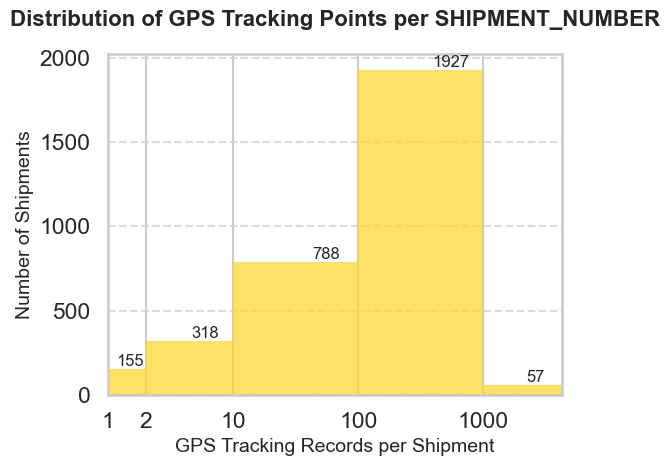

In [149]:
import seaborn as sns
import matplotlib.pyplot as plt

# Simulated gps_record_counts for demonstration purposes (adjust according to your real dataset)
gps_record_counts = gps_df['SHIPMENT_NUMBER'].value_counts()

# Define bins with a range to ensure proper monotonic order
bins = [1, 2, 10, 100, 1000, gps_record_counts.max() + 1]  # Adding max+1 to cover the largest range
sns.set_style("whitegrid")  # White background with grid
sns.set_context("talk")  # Set the context to make fonts clearer

# Plot the histogram using Seaborn
plt.figure(figsize=(6, 5))
hist = sns.histplot(gps_record_counts, bins=bins, kde=False, color='#fdd835', edgecolor='black')

# Customize the x-axis with log scale and custom labels
plt.xscale('log')
plt.xticks([1, 2, 10, 100, 1000], labels=['1', '2', '10', '100', '1000'])
plt.xlim(bins[0], bins[-1])


# Adding labels and title
plt.title('Distribution of GPS Tracking Points per SHIPMENT_NUMBER', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('GPS Tracking Records per Shipment', fontsize=14)
plt.ylabel('Number of Shipments', fontsize=14)

for patch in hist.patches:
    height = patch.get_height()
    if height > 0:
        plt.text(patch.get_x() + patch.get_width() / 2, height, f'{int(height)}', 
                 ha='center', va='bottom', fontsize=12)

# Customize the grid and layout
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()

### 2. Variation in GPS Collection Frequency

The following block shows significant variation in GPS signal frequency between different shipments. Based on the analysis, the 25th percentile for GPS signal frequency is **0.89 signals per 5 minutes**, the median (50th percentile) is **2.42 signals per 5 minutes**, and the 75th percentile is **3.50 signals per 5 minutes**.

The range of GPS signal frequencies suggests that while some shipments are more tracked with high-frequency updates, others may have less frequent tracking, potentially affecting the accuracy of delivery time estimation and overall tracking reliability. The reasons could be realated to the carrier devices, tracking preferences or signal quality.

GPS Frequency per 5 Minutes - Major Quartiles:
25th Percentile: 0.89 signals per 5 minutes
50th Percentile (Median): 2.42 signals per 5 minutes
75th Percentile: 3.50 signals per 5 minutes


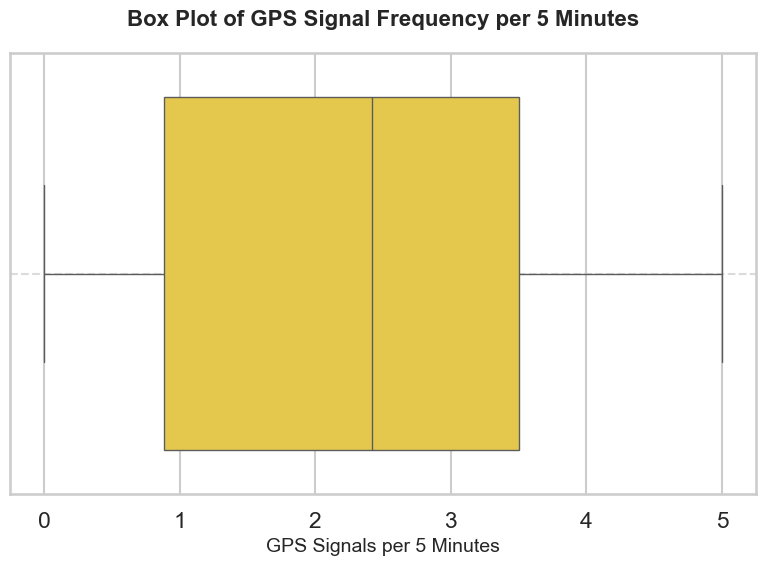

In [150]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Calculate the time difference between consecutive GPS points for each shipment
gps_df['prev_timestamp'] = gps_df.groupby('SHIPMENT_NUMBER')['RECORD_TIMESTAMP'].shift(1)
gps_df['time_diff_minutes'] = (gps_df['RECORD_TIMESTAMP'] - gps_df['prev_timestamp']).dt.total_seconds() / 60

# Step 2: Calculate the GPS signal frequency per 5 minutes for each shipment
gps_frequency_per_5_min = gps_df.groupby('SHIPMENT_NUMBER')['time_diff_minutes'].apply(
    lambda x: (5 / x.mean()) if x.mean() > 0 else 0)

# Step 3: Calculate the quartiles and median
gps_frequency_quartiles = np.percentile(gps_frequency_per_5_min, [25, 50, 75])  # 25th, 50th (median), 75th percentiles

# Print the quartile values
print("GPS Frequency per 5 Minutes - Major Quartiles:")
print(f"25th Percentile: {gps_frequency_quartiles[0]:.2f} signals per 5 minutes")
print(f"50th Percentile (Median): {gps_frequency_quartiles[1]:.2f} signals per 5 minutes")
print(f"75th Percentile: {gps_frequency_quartiles[2]:.2f} signals per 5 minutes")

# Step 4: Create a box plot using Seaborn
plt.figure(figsize=(8, 6))
sns.boxplot(x=gps_frequency_per_5_min, color='#fdd835')

# Step 5: Add title and labels
plt.title('Box Plot of GPS Signal Frequency per 5 Minutes', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('GPS Signals per 5 Minutes', fontsize=14)

# Step 6: Display the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 2. Shipments with Only One GPS Record

Some shipments contain only a single GPS record. We will classify these as opted-out carriers, as the limited data suggests minimal or no active tracking during the shipment.

In [151]:
# Count the number of SHIPMENT_NUMBERs in gps_df that have only one row
single_row_shipments = gps_df['SHIPMENT_NUMBER'].value_counts()[gps_df['SHIPMENT_NUMBER'].value_counts() == 1]

# Count how many shipment numbers have only one row
single_row_shipments_count = single_row_shipments.count()

# Display the result
print(f"Number of shipment that belong to opted-out carriers: {single_row_shipments_count}")

Number of shipment that belong to opted-out carriers: 155


### Helper Function to Calculate the Distance Between Two GPS Coordinates

This function will be used in multiple code blocks, so it's defined separately for reuse.

The function uses the `geopy` library to estimate the distance between two GPS coordinates. While this provides a reasonable approximation, it is not fully accurate for land transportation use-cases. A more precise approach would leverage a mapping API (e.g., Google Maps) to calculate road-based distances between coordinates.

In [152]:
from geopy.distance import geodesic

def calculate_distance(lat1, lon1, lat2, lon2):
    return geodesic((lat1, lon1), (lat2, lon2)).miles

### 3. GPS Data Can Stop Suddenly While Still Far from the Destination

The observation below illustrates that GPS tracking can abruptly stop during a trip. This can happen for several reasons, including weak signal, device malfunction (e.g., low battery), incomplete data transmission to the server, or intentional deactivation by the carrier. These scenarios must be carefully considered when building the final solution.

The following code block demonstrates how to detect these cases. At the end of the block, we display an example where the `distance_to_delivery` column shows the shipment getting closer to the destination, but the GPS tracking then stops, leaving the shipment still far from the destination.

In [153]:
# Step 1: Merge ship_bks_df and gps_df on SHIPMENT_NUMBER
merged_df = gps_df.merge(ship_bks_df, on='SHIPMENT_NUMBER', how='inner')

# Step 2: Calculate the distance between each GPS point and the delivery location (destination)
merged_df['distance_to_delivery'] = merged_df.apply(
    lambda row: calculate_distance(row['LAT'], row['LON'], row['LAST_DELIVERY_LATITUDE'], row['LAST_DELIVERY_LONGITUDE']),
    axis=1
)

# Step 3: Identify shipments where all GPS points are more than 50 miles away from the destination
# Group by SHIPMENT_NUMBER and check if all distances for that shipment are greater than 50 miles
shipments_far_from_destination = merged_df.groupby('SHIPMENT_NUMBER').filter(
    lambda group: (group['distance_to_delivery'] > 50).all()
)

# Step 4: Display an example of GPS tracking records for such shipments
example_shipments = shipments_far_from_destination['SHIPMENT_NUMBER'].unique()[:1]  # Pick one example
example_tracking = shipments_far_from_destination[shipments_far_from_destination['SHIPMENT_NUMBER'].isin(example_shipments)]

# Step 5: Sort example_tracking explicitly by RECORD_TIMESTAMP to ensure correct chronological order
example_tracking = example_tracking.sort_values(by='RECORD_TIMESTAMP')

# Show the example tracking records, ensuring they are in chronological order
example_tracking[['SHIPMENT_NUMBER', 'RECORD_TIMESTAMP', 'LAT', 'LON', 'distance_to_delivery']]

,SHIPMENT_NUMBER,RECORD_TIMESTAMP,LAT,LON,distance_to_delivery
1207,SEZHUK-230922-246668,2023-10-30 16:28:00+00:00,52.358919,-1.171335,263.392894
1208,SEZHUK-230922-246668,2023-10-30 16:30:00+00:00,52.358489,-1.171629,263.414020
1209,SEZHUK-230922-246668,2023-10-30 16:31:00+00:00,52.358121,-1.171151,263.445818
1210,SEZHUK-230922-246668,2023-10-30 16:32:00+00:00,52.357997,-1.169315,263.488015
1211,SEZHUK-230922-246668,2023-10-30 16:34:00+00:00,52.355125,-1.165972,263.728766
...,...,...,...,...,...
1466,SEZHUK-230922-246668,2023-10-30 21:26:00+00:00,54.682362,-2.787588,91.034965
1467,SEZHUK-230922-246668,2023-10-30 21:27:00+00:00,54.687234,-2.790861,90.685771
1468,SEZHUK-230922-246668,2023-10-30 21:28:00+00:00,54.697079,-2.791510,90.122889
1469,SEZHUK-230922-246668,2023-10-30 21:29:00+00:00,54.712097,-2.795094,89.204897


### 4. Some Tracking Data Shows the Shipment Getting Closer, Then Moving Further Away

In some cases, it appears that the carrier may have forgotten to mark the delivery as completed in the app, resulting in continued GPS tracking even after arriving near the destination.

**Conclusion**: The last GPS record for a shipment (in terms of time) is not always the closest to the destination geographically.

In the next cell, I will present an example of this scenario. Notice how the `distance_to_delivery` reaches near-zero at `2023-11-30 15:36:00+00:00` (forth row), but then increases afterward, indicating the shipment was moving away from the destination after coming very close.

In [154]:
# Step 1: Sort the data by SHIPMENT_NUMBER and RECORD_TIMESTAMP to ensure correct order of GPS points
merged_df = merged_df.sort_values(by=['SHIPMENT_NUMBER', 'RECORD_TIMESTAMP'])

# Step 2: Calculate the change in distance to the destination for each GPS point
# Calculate the difference in distance between consecutive rows for each shipment
merged_df['distance_change'] = merged_df.groupby('SHIPMENT_NUMBER')['distance_to_delivery'].diff()

# Step 3: Identify shipments where the distance first decreases and then increases (i.e., got closer and then moved farther)
# We're looking for shipments where distance_change is negative (getting closer) followed by a positive (moving away)
# We'll group by SHIPMENT_NUMBER and check for this pattern in each shipment's data

def find_backtrack(group):
    # Check if there's any negative change followed by a positive change
    distance_changes = group['distance_change'].dropna().values  # Get the distance changes, ignoring NaN
    for i in range(1, len(distance_changes)):
        if distance_changes[i - 1] < 0 and distance_changes[i] > 0:
            return True
    return False

# Step 4: Filter for shipments where this backtracking pattern occurs
shipments_with_backtracking = merged_df.groupby('SHIPMENT_NUMBER').filter(find_backtrack)

# Step 5: Display an example of such shipments
example_backtracking_shipments = shipments_with_backtracking['SHIPMENT_NUMBER'].unique()[:3]  # Pick one example
example_backtracking = merged_df[merged_df['SHIPMENT_NUMBER'].isin(example_backtracking_shipments)]

# Show the example tracking records
example_backtracking[['SHIPMENT_NUMBER', 'RECORD_TIMESTAMP', 'LAT', 'LON', 'distance_to_delivery']].tail(140)

,SHIPMENT_NUMBER,RECORD_TIMESTAMP,LAT,LON,distance_to_delivery
112,SEZHUK-230919-245487,2023-11-30 15:19:00+00:00,53.260184,-1.319879,0.114933
113,SEZHUK-230919-245487,2023-11-30 15:34:00+00:00,53.260418,-1.319187,0.140908
114,SEZHUK-230919-245487,2023-11-30 15:35:00+00:00,53.260136,-1.319792,0.112934
115,SEZHUK-230919-245487,2023-11-30 15:36:00+00:00,53.259678,-1.319897,0.081971
116,SEZHUK-230919-245487,2023-11-30 15:52:00+00:00,53.260132,-1.319797,0.112636
...,...,...,...,...,...
247,SEZHUK-230919-245489,2023-11-09 17:47:00+00:00,52.891568,-1.452995,25.971570
248,SEZHUK-230919-245489,2023-11-09 17:48:00+00:00,52.893864,-1.454477,25.829619
249,SEZHUK-230919-245489,2023-11-09 17:49:00+00:00,52.899789,-1.458140,25.463458
250,SEZHUK-230919-245489,2023-11-09 17:50:00+00:00,52.906029,-1.462872,25.088858


# Estimate the Percentage of On-Time Delivery

## Assumptions
The following assumptions guide the analysis:

* Shipments with only one GPS tracking record are considered opted-out from tracking.
* Carriers may leave GPS tracking running after delivery.
* GPS tracking can stop unexpectedly (possible reasons due to poor signal, device issues, or carrier intervention).
* A shipment is considered successfully delivered when it reaches within 0.5 miles of the destination.
* Delivery time estimation accuracy improves as the distance to the destination decreases:
  * **Certain**: If the closest tracked point is ≤ 0.5 miles from the destination.
  * **High Confidence**: If the closest point is between 0.5 and 50 miles.
  * **Moderate Confidence**: If the closest point is more than 50 miles away.

## Approach

1. **Eliminate opted-out records**: These records lack sufficient GPS data to determine on-time delivery.
2. **Merge datasets**: Combine the GPS and shipment booking data, filtering for shipments scheduled between 1st October 2023 and 31st December 2023.
3. **Clean invalid GPS data**: Remove records with LAT and LONG values of zero, ensuring only valid GPS points are analyzed.
4. **Calculate speed and remaining distance**:
   * For each shipment, order GPS records by `RECORD_TIMESTAMP`.
   * Calculate the remaining distance to the destination at each point, and approximate the speed based on the previous GPS point.
5. **Identify closest GPS point**: For each shipment, select the GPS point closest to the destination.
6. **Estimate remaining time**: Based on the most recent speed and the closest GPS point, calculate the time needed to reach the destination.
7. **Determine on-time status**: Add the estimated remaining time to the `RECORD_TIMESTAMP` of the closest GPS point. Check if it falls within the delivery window, i.e., no later than `LAST_DELIVERY_SCHEDULE_LATEST + 30 minutes`.


In [155]:
import pandas as pd

# Step 1: Filter out shipments with only one GPS record (opted-out shipments)
gps_record_counts = gps_df['SHIPMENT_NUMBER'].value_counts()
opted_in_shipments = gps_record_counts[gps_record_counts > 1].index
opted_in_gps_df = gps_df[gps_df['SHIPMENT_NUMBER'].isin(opted_in_shipments)]

# Step 2: Remove invalid GPS records (coordinates with LAT and LON equal to 0)
opted_in_gps_df = opted_in_gps_df[(opted_in_gps_df['LAT'] != 0) & (opted_in_gps_df['LON'] != 0)]

# Step 3: Merge the filtered GPS data with the shipment booking data based on SHIPMENT_NUMBER
merged_df = opted_in_gps_df.merge(ship_bks_df, on='SHIPMENT_NUMBER', how='inner')

# Step 4: Filter shipments to include only those scheduled between October 1st and December 31st, 2023
start_date = pd.Timestamp('2023-10-01', tz='UTC')
end_date = pd.Timestamp('2023-12-31 23:59:59', tz='UTC')
filtered_df = merged_df[(merged_df['FIRST_COLLECTION_SCHEDULE_EARLIEST'] >= start_date) & 
                        (merged_df['LAST_DELIVERY_SCHEDULE_LATEST'] <= end_date)].copy()

# Step 5: Calculate the distance between each GPS point and the delivery location (destination)
filtered_df['distance_to_delivery'] = filtered_df.apply(
    lambda row: calculate_distance(row['LAT'], row['LON'], row['LAST_DELIVERY_LATITUDE'], row['LAST_DELIVERY_LONGITUDE']), 
    axis=1
)

# Step 6: Calculate the distance travelled and speed between consecutive GPS points
# Shift the LAT, LON, and RECORD_TIMESTAMP to get the previous GPS point for each shipment
filtered_df.loc[:, 'prev_lat'] = filtered_df.groupby('SHIPMENT_NUMBER')['LAT'].shift(1)
filtered_df.loc[:, 'prev_lon'] = filtered_df.groupby('SHIPMENT_NUMBER')['LON'].shift(1)
filtered_df.loc[:, 'prev_timestamp'] = filtered_df.groupby('SHIPMENT_NUMBER')['RECORD_TIMESTAMP'].shift(1)

# Calculate the distance between consecutive points
filtered_df['distance_travelled'] = filtered_df.apply(
    lambda row: calculate_distance(row['LAT'], row['LON'], row['prev_lat'], row['prev_lon']) if pd.notna(row['prev_lat']) else 0, axis=1
)

# Calculate the time difference between consecutive points (in hours)
filtered_df['time_diff_hours'] = (filtered_df['RECORD_TIMESTAMP'] - filtered_df['prev_timestamp']).dt.total_seconds() / 3600

# Calculate the speed (distance over time), handle cases where time_diff_hours is zero to avoid division by zero
filtered_df['speed_mph'] = filtered_df.apply(
    lambda row: row['distance_travelled'] / row['time_diff_hours'] if row['time_diff_hours'] > 0 else 0, axis=1
)

# Step 7: Calculate GPS frequency per 5 minutes for each shipment
filtered_df['time_diff_minutes'] = (filtered_df['RECORD_TIMESTAMP'] - filtered_df['prev_timestamp']).dt.total_seconds() / 60
filtered_df['gps_frequency_per_5_min'] = filtered_df.groupby('SHIPMENT_NUMBER')['time_diff_minutes'].transform(
    lambda x: 5 / x.mean() if x.mean() > 0 else 0
)

# Step 8: Find the closest GPS record to the delivery point for each SHIPMENT_NUMBER
closest_records = filtered_df.loc[filtered_df.groupby('SHIPMENT_NUMBER')['distance_to_delivery'].idxmin()]

# Step 9: Estimate the remaining time to reach the destination using the current speed or a fallback speed
fallback_speed = 20  # Default speed in mph if current speed is too low
closest_records['remaining_time_minutes'] = closest_records.apply(
    lambda row: (row['distance_to_delivery'] / row['speed_mph']) * 60 if row['speed_mph'] > 20 else (row['distance_to_delivery'] / fallback_speed) * 60, axis=1
)

# Step 10: Estimate the arrival time by adding the remaining time to the last known GPS timestamp
closest_records['estimated_arrival_time'] = closest_records['RECORD_TIMESTAMP'] + pd.to_timedelta(closest_records['remaining_time_minutes'], unit='m')

# Step 11: Determine if the estimated arrival time is within the allowed delivery window (LAST_DELIVERY_SCHEDULE_LATEST + 30 minutes)
closest_records['on_time_estimation'] = closest_records['estimated_arrival_time'] <= (closest_records['LAST_DELIVERY_SCHEDULE_LATEST'] + pd.Timedelta(minutes=30))

### Categorizing On-Time Delivery Confidence Based on Proximity and GPS Data Frequency

In this approach, we assess the confidence level for each shipment's estimated on-time delivery based on two key factors: the **proximity** of the closest GPS record to the delivery destination and the **frequency** of GPS signal collection during the shipment.

#### Key Steps:
1. **Delivery Confidence Categorization**: We classify shipments into four confidence levels by combining the proximity to the delivery point with the frequency of GPS data collection:
   - **Certain**: The closest GPS record is within 0.5 miles of the destination.
   - **High Confidence**: The closest GPS record is between 0.5 and 50 miles from the destination, with a GPS frequency higher than or equal to the median frequency.
   - **Moderate Confidence**: If the closest GPS record is between 0.5 and 50 miles from the destination, but the GPS frequency is **less than the median**, we classify it as **Moderate Confidence**. This also applies to shipments tracked more than 50 miles away with a GPS frequency higher than or equal to the median.
   - **Low Confidence**: The shipment is tracked more than 50 miles from the destination, with a GPS frequency lower than the median.
2. **On-Time and Late Shipments**: We filter shipments estimated to arrive on time and classify them into these confidence levels. We also calculate the number of shipments that are estimated to arrive late.
3. **Opted-Out Shipments**: Shipments with only one GPS record are treated as having opted out from tracking, and we calculate the percentage of these shipments.
4. **Final Results**: The final output will display the percentage of on-time deliveries, broken down by confidence level, alongside the percentages of late and opted-out shipments.

This method provides a robust view of delivery performance by considering both the accuracy of GPS tracking based on proximity and the reliability of the tracking frequency. Combining these two parameters allows us to better estimate the confidence in delivery timing, giving a more nuanced understanding of shipment performance.

In [156]:
# Categorise based on proximity and GPS record count
def categorize_delivery_estimation(row):
    distance = row['distance_to_delivery']
    gps_frequency = row['gps_frequency_per_5_min']
    
    if distance <= 0.5:
        return 'Certain'
    elif distance >= 0.5 and distance <= 50:
        if gps_frequency >= gps_frequency_quartiles[1]:
            return 'High Confidence'
        else:
            return 'Moderate Confidence'
    else: # this meanse that distance > 50 miles
        if gps_frequency >= gps_frequency_quartiles[1]:
            return 'Moderate Confidence'
        else:
            return 'Low Confidence'

# Step 1: Apply the confidence categorization
closest_records['delivery_estimation_category'] = closest_records.apply(
    lambda row: categorize_delivery_estimation(row), axis=1
)

# Step 2: Filter on-time shipments and classify into categories
on_time_shipments_df = closest_records[closest_records['on_time_estimation'] == True]
on_time_certain = on_time_shipments_df[on_time_shipments_df['delivery_estimation_category'] == 'Certain']['SHIPMENT_NUMBER'].nunique()
on_time_high_confidence = on_time_shipments_df[on_time_shipments_df['delivery_estimation_category'] == 'High Confidence']['SHIPMENT_NUMBER'].nunique()
on_time_moderate_confidence = on_time_shipments_df[on_time_shipments_df['delivery_estimation_category'] == 'Moderate Confidence']['SHIPMENT_NUMBER'].nunique()
on_time_low_confidence = on_time_shipments_df[on_time_shipments_df['delivery_estimation_category'] == 'Low Confidence']['SHIPMENT_NUMBER'].nunique()


# Step 3: Calculate the total number of shipments
total_opted_in_shipments = closest_records['SHIPMENT_NUMBER'].nunique()

# Step 4: Calculate the number of late shipments
late_shipments = closest_records[closest_records['on_time_estimation'] == False]['SHIPMENT_NUMBER'].nunique()

# Step 5: Calculate the number of shipments opted out of GPS tracking (filtered by date range)
valid_shipments_in_gps = gps_df.merge(ship_bks_df, on='SHIPMENT_NUMBER', how='inner')
valid_shipments_in_gps = valid_shipments_in_gps[
    (valid_shipments_in_gps['FIRST_COLLECTION_SCHEDULE_EARLIEST'] >= start_date) &
    (valid_shipments_in_gps['LAST_DELIVERY_SCHEDULE_LATEST'] <= end_date)
]

total_shipments_in_gps_df = valid_shipments_in_gps['SHIPMENT_NUMBER'].nunique()
opted_out_shipments = total_shipments_in_gps_df - total_opted_in_shipments

# Step 6: Calculate percentages
on_time_shipments = on_time_certain + on_time_high_confidence + on_time_moderate_confidence + on_time_low_confidence
on_time_percentage = (on_time_shipments / total_shipments_in_gps_df) * 100
late_percentage = (late_shipments / total_shipments_in_gps_df) * 100
opted_out_percentage = (opted_out_shipments / total_shipments_in_gps_df) * 100

# Step 7: Display the final results with confidence levels
print(f"Total shipments analysed: {total_shipments_in_gps_df}")
print(f"Percentage of shipments estimated to arrive on time: {on_time_percentage:.2f}%  "
      f"({on_time_shipments} shipments, {on_time_certain} certain, {on_time_high_confidence} high confidence, {on_time_moderate_confidence} moderate confidence, {on_time_low_confidence} low confidence)")
print(f"Percentage of shipments estimated to arrive late: {late_percentage:.2f}%  ({late_shipments} shipments)")
print(f"Percentage of shipments opted out of GPS tracking: {opted_out_percentage:.2f}%  ({opted_out_shipments} shipments)")

Total shipments analysed: 3237
Percentage of shipments estimated to arrive on time: 68.89%  (2230 shipments, 1648 certain, 177 high confidence, 249 moderate confidence), 156 low confidence)
Percentage of shipments estimated to arrive late: 26.32%  (852 shipments)
Percentage of shipments opted out of GPS tracking: 4.79%  (155 shipments)


# Storing Shipment Data as a Training Set with Ground Truth

For the upcoming task, we will need to work with the shipment data as a training set, including the associated ground truth. The ground truth is captured in the on_time_estimation column, a boolean indicator that specifies whether a shipment was delivered on time or not. This data will be crucial for validating our predictions in the next task.

We will store this data in a CSV file named shipment_bookings_train.csv, which can be read and used in the subsequent task.

In [159]:
closest_records[['SHIPMENT_NUMBER', 'CARRIER_ID', 'VEHICLE_SIZE', 'VEHICLE_BUILD_UP', 'FIRST_COLLECTION_POST_CODE', 'LAST_DELIVERY_POST_CODE', 'FIRST_COLLECTION_LATITUDE',
                'FIRST_COLLECTION_LONGITUDE', 'LAST_DELIVERY_LATITUDE', 'LAST_DELIVERY_LONGITUDE', 'FIRST_COLLECTION_SCHEDULE_EARLIEST', 'FIRST_COLLECTION_SCHEDULE_LATEST',
                'LAST_DELIVERY_SCHEDULE_EARLIEST', 'LAST_DELIVERY_SCHEDULE_LATEST', 'on_time_estimation']].to_csv('./data/shipment_bookings_train.csv', index=False)

# Conclusion

This analysis focused on evaluating shipment performance through GPS tracking data, specifically estimating on-time deliveries based on proximity to the destination and GPS signal frequency. The workflow incorporated exploratory analysis, error identification, and a structured approach to categorizing delivery confidence.

### Key Observations:
1. **GPS Tracking Variability**: Shipments showed significant variation in the number of GPS records, ranging from a single signal to thousands. This variability, likely due to differing device configurations or carrier preferences, required special handling. Shipments with only one GPS record were classified as **opted-out** from tracking.
2. **GPS Data Quality Issues**: We identified three outlier records with LAT and LON values set to 0.0, two of which belonged to shipments that had opted out of tracking, and one occurred in the middle of a journey, suggesting a data collection error. This latest anomaly was filtered out to ensure data accuracy.
3. **Incorrect Shipment Windows**: Some shipment records contained scheduling errors (e.g., the earliest collection time being later than the latest), indicating input mistakes that should be validated before entry into the database.
4. **GPS Data Gaps**: The analysis revealed cases where GPS data stopped prematurely, indicating possible signal loss, device failure, or intentional deactivation by carriers. These scenarios were captured, and strategies for handling them were proposed.
5. **Backtracking Issues**: Several shipments displayed GPS backtracking, where the vehicle moved away from the delivery point after getting close. This likely resulted from the carrier failing to mark the delivery as completed in the system.

### On-Time Delivery Estimation and Confidence Categorization:
- Using GPS tracking data, we estimated on-time delivery by calculating the proximity to the destination and comparing it to scheduled delivery windows.
- Shipments were categorized into confidence levels:
  - **Certain**: Shipments tracked within 0.5 miles of the destination.
  - **High Confidence**: Shipments tracked between 0.5 and 50 miles with frequent GPS signals.
  - **Moderate Confidence**: Shipments within 0.5-50 miles but with lower GPS frequency or shipments over 50 miles away with higher frequency.
  - **Low Confidence**: Shipments over 50 miles away with low GPS signal frequency.
- This multi-level categorization, combined with time-based estimations, offered a nuanced approach to determining the reliability of on-time deliveries.

### Final Results:
- The percentage of on-time deliveries was calculated, with shipments broken down by confidence levels.
- Late deliveries and shipments that opted out of GPS tracking were also quantified to provide a comprehensive view of carrier performance.